# XGBoost

In [2]:
# Data Handling and Analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

###
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

###
import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
# Read csv file and look at contents
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(file_path, sep=";", na_values=["", " ", "NA", "N/A", "nan", "NaN"])

print(df.shape)
print(df.head())

# Proportions of classes
print("Value Counts (in %):")
class_shares = df["OUTCOME_3Kat_KHK"].value_counts(normalize=True) * 100
print(class_shares.round(2))
print("Number of nan")
print(df.isnull().sum())
df.isnull().sum().sort_values(ascending=False).head(20)

# Gesamtanzahl leerer Zellen im gesamten DataFrame
print("Gesamtanzahl Zellen:", df.size)
print("Gesamtanzahl leerer Zellen:", df.isnull().sum().sum())

(2310, 649)
   OUTCOME_3Kat_KHK           Alter_0  geschlecht waist_0             WHR_0  \
0                 2  56,9691991786448           0     112  ,982456140350877   
1                 2  69,4976043805613           0     104              1,04   
2                 2  72,0492813141684           0     129  ,941605839416058   
3                 2  70,8145106091718           0      99  ,876106194690266   
4                 2  62,1601642710472           1     125               NaN   

              BMI_0  currsmo0  RR_syst_0  RR_diast_0  Pulse_Pressure  ...  \
0  32,8731097961867         0      130.0        80.0            50.0  ...   
1  30,1102788964583         0      160.0        70.0            90.0  ...   
2  44,7348800491207         0      140.0        90.0            50.0  ...   
3  26,2595847484332         0      130.0        90.0            40.0  ...   
4  42,4366343891054         1      180.0       100.0            80.0  ...   

   SMC231l  SMC232l  SMC233l  SMC240l  SMC241l SMC

/var/folders/rp/sz_1shj9783116jtrj1kc04m0000gn/T/ipykernel_27473/2271635866.py:3: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=";", na_values=["", " ", "NA", "N/A", "nan", "NaN"])


## FIRST TRY

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

# ---------------------------
# 1) Load data
# ---------------------------
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None]
)

# ---------------------------
# 2) Clean structure
#    - Drop columns that are mostly empty (>95% NaN)
#    - Drop rows that are entirely empty
# ---------------------------
before_cols = set(df.columns)
df = df.dropna(axis=1, thresh=len(df) * 0.05)  # keep cols with >=5% non-NaN
df = df.dropna(how="all")
dropped_cols = sorted(list(before_cols - set(df.columns)))

# ---------------------------
# 3) Target / features
# ---------------------------
target_col = "OUTCOME_3Kat_KHK"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found after cleaning.")

# remove rows where target is missing
df = df[df[target_col].notna()]

X = df.drop(columns=[target_col])
y = df[target_col]

# ---------------------------
# 4) Encode categoricals (XGBoost needs numeric)
#    (keep NaNs; XGBoost can handle them)
# ---------------------------
X = pd.get_dummies(X, drop_first=True)

# ---------------------------
# 5) Train-test split (stratified)
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Helpful: class distribution
print("Class distribution (train):")
print(y_train.value_counts(normalize=True).sort_index())
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True).sort_index())
print()

# ---------------------------
# 6) Class weights (multiclass) -> sample_weight
# ---------------------------
classes = np.unique(y_train)
class_wts = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
wt_map = {c: w for c, w in zip(classes, class_wts)}
sw_train = y_train.map(wt_map).values

print("Class weights used:")
for c in classes:
    print(f"  class {c}: {wt_map[c]:.4f}")
print()

# ---------------------------
# 7) XGBoost model
# ---------------------------
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss",
    # tree_method="hist",  # uncomment for speed on larger data
)

# Fit with sample weights (handles imbalance)
xgb_model.fit(
    X_train, y_train,
    sample_weight=sw_train,
    eval_set=[(X_test, y_test)],  # simple monitoring
    verbose=False
)

# ---------------------------
# 8) Evaluation
# ---------------------------
y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ---------------------------
# 9) (Optional) Show what was dropped
# ---------------------------
if dropped_cols:
    print("\nDropped columns (>95% missing):")
    for c in dropped_cols:
        print(" -", c)

# Quick check of remaining missingness (X can still contain NaNs)
missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)
print("\nTop 10 features by remaining missingness in X (post-encoding):")
print(missing_pct.head(10).round(2))

# ---------------------------
# 10) Multiclass ROC and Precision–Recall curves (OvR)
# ---------------------------
# Predict probabilities
y_score = xgb_model.predict_proba(X_test)

# Ensure consistent class order
classes_model = np.array(xgb_model.classes_)  # e.g., [0,1,2]
y_test_bin = label_binarize(y_test, classes=classes_model)

# Containers
fpr, tpr, roc_auc = {}, {}, {}
precision, recall, avg_precision = {}, {}, {}

valid_classes_roc = []
valid_classes_pr = []

# Per-class curves (skip classes without positives/negatives as needed)
for i, c in enumerate(classes_model):
    y_true_i = y_test_bin[:, i]
    y_score_i = y_score[:, i]

    # ROC needs both positives and negatives
    if y_true_i.any() and (~y_true_i.astype(bool)).any():
        fpr[i], tpr[i], _ = roc_curve(y_true_i, y_score_i)
        roc_auc[i] = auc(fpr[i], tpr[i])
        valid_classes_roc.append(i)

    # PR needs at least one positive
    if y_true_i.any():
        precision[i], recall[i], _ = precision_recall_curve(y_true_i, y_score_i)
        avg_precision[i] = average_precision_score(y_true_i, y_score_i)
        valid_classes_pr.append(i)

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
avg_precision["micro"] = average_precision_score(y_test_bin, y_score, average="micro")

# Macro-average (mean over available classes)
roc_auc["macro"] = float(np.mean([roc_auc[i] for i in valid_classes_roc])) if valid_classes_roc else np.nan
avg_precision["macro"] = float(np.mean([avg_precision[i] for i in valid_classes_pr])) if valid_classes_pr else np.nan

print(f"\nROC AUC — micro: {roc_auc['micro']:.3f}, macro: {roc_auc['macro']:.3f}")
print(f"Avg Precision — micro: {avg_precision['micro']:.3f}, macro: {avg_precision['macro']:.3f}")

/var/folders/rp/sz_1shj9783116jtrj1kc04m0000gn/T/ipykernel_27473/2187469483.py:25: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Class distribution (train):
OUTCOME_3Kat_KHK
0    0.156926
1    0.273810
2    0.569264
Name: proportion, dtype: float64

Class distribution (test):
OUTCOME_3Kat_KHK
0    0.158009
1    0.272727
2    0.569264
Name: proportion, dtype: float64

Class weights used:
  class 0: 2.1241
  class 1: 1.2174
  class 2: 0.5856



/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:58:16] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1758007651359/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.5476190476190477
Balanced accuracy: 0.4782941737210189
Macro F1: 0.4690663563057502

Confusion Matrix:
 [[ 34  22  17]
 [ 25  33  68]
 [ 29  48 186]]

Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.47      0.42        73
           1       0.32      0.26      0.29       126
           2       0.69      0.71      0.70       263

    accuracy                           0.55       462
   macro avg       0.46      0.48      0.47       462
weighted avg       0.54      0.55      0.54       462


Dropped columns (>95% missing):
 - @12SHETE
 - @15SHETE
 - @9SHODE
 - LTB4
 - PGD2
 - PGE2
 - PGaaC341l
 - PGaaC361l
 - PGaaC362l

Top 10 features by remaining missingness in X (post-encoding):
xLeu            93.07
PCaaC342        93.07
lysoPCaC160     93.07
H1              93.07
PCaaC362        93.07
PCaaC342l       82.60
Ala             82.55
Val             82.55
H1_energy_m     82.55
Lac_energy_m    82.55
dtype: float64

R

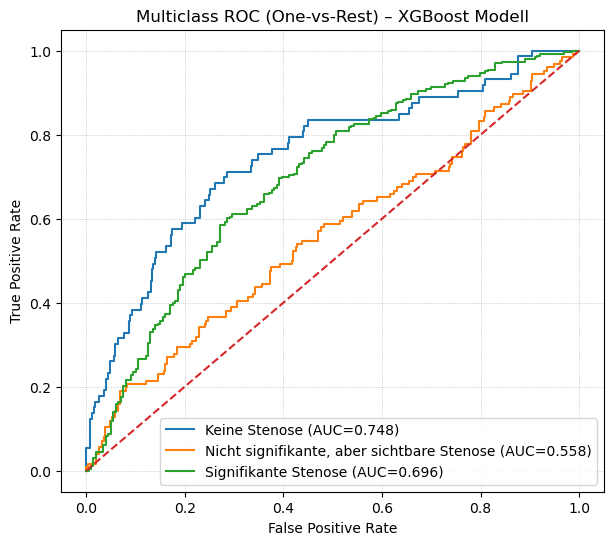

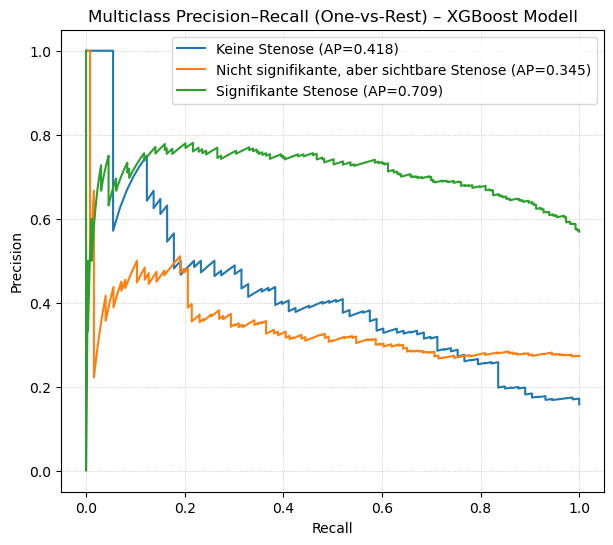

In [5]:
# Klassen-Beschriftungen definieren
class_labels = {
    0: "Keine Stenose",
    1: "Nicht signifikante, aber sichtbare Stenose",
    2: "Signifikante Stenose"
}

# ROC plot 
plt.figure(figsize=(7, 6))
for i in valid_classes_roc:
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC={roc_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC (One-vs-Rest) – XGBoost Modell")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.show()

# Precision–Recall plot
plt.figure(figsize=(7, 6))
for i in valid_classes_pr:
    plt.plot(recall[i], precision[i], label=f"{class_labels[i]} (AP={avg_precision[i]:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass Precision–Recall (One-vs-Rest) – XGBoost Modell")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.show()


## SMOTE VARIANT, MULTI-CLASS

Dropped 548 cols (> 75% missing).
Class dist (train):
OUTCOME_3Kat_KHK
0    0.156926
1    0.273810
2    0.569264
Name: proportion, dtype: float64 

Numeric cols: 100 | Categorical (low-card) cols: 0
After SMOTENC/SMOTE class dist (train):
0    0.272688
1    0.272688
2    0.454624
Name: proportion, dtype: float64
Train size before: 1848 -> after: 2314
SMOTE k_neighbors=3, target_ratio=0.6

Early stopping used: False
Accuracy: 0.5844155844155844
Balanced accuracy: 0.4624255672487351
Macro F1: 0.4624918161025091

Confusion Matrix:
 [[ 26  17  30]
 [ 16  25  85]
 [ 15  29 219]]

Classification Report:
               precision    recall  f1-score   support

           0      0.456     0.356     0.400        73
           1      0.352     0.198     0.254       126
           2      0.656     0.833     0.734       263

    accuracy                          0.584       462
   macro avg      0.488     0.462     0.462       462
weighted avg      0.541     0.584     0.550       462


ROC AUC — mi

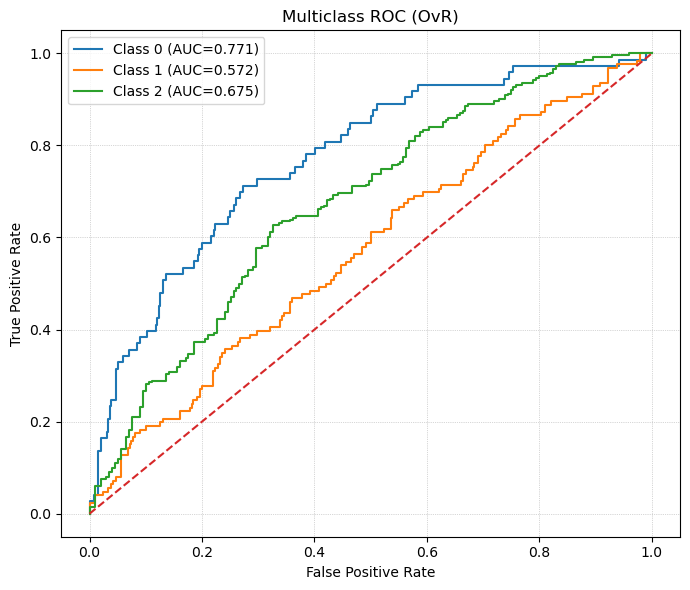

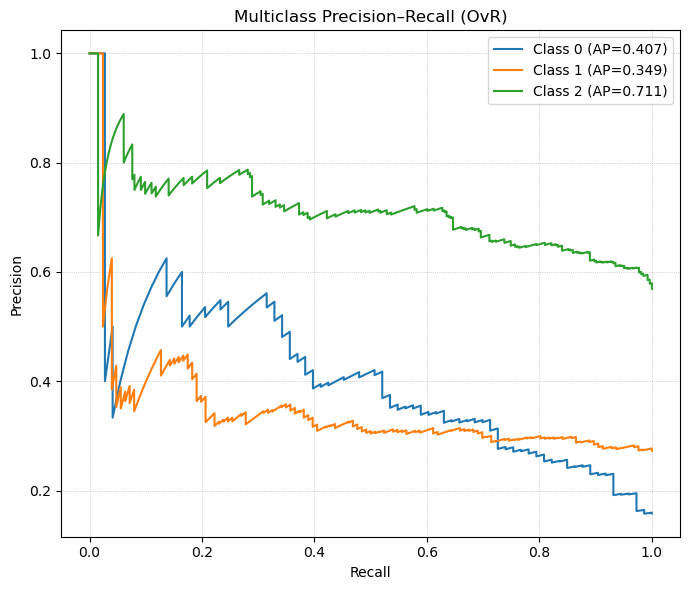


Final shapes: X_train_enc=(2314, 100), X_test_enc=(462, 100)


In [6]:
# Multiclass XGBoost + SMOTENC (schnellere Variante, ohne n_jobs)
# - Drop >75% missing
# - Numerisch aussehende Strings -> Float (Dezimal-Komma)
# - Imputation NUR auf Train (median / most_frequent)
# - SMOTENC vor One-Hot, Minderheiten auf 60% der Mehrheit (statt voll)
# - One-Hot erst NACH SMOTE
# - Early Stopping, ROC/PR micro & macro

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

# ---------------------------
# 1) Load + parse numeric-like strings
# ---------------------------
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
    low_memory=False
)

# numeric-looking objects -> float
obj_cols = df.select_dtypes(exclude=np.number).columns
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
    if num.notna().mean() >= 0.80:
        df[c] = num

# ---------------------------
# 2) Drop columns with >75% missing (speed) + remove empty rows
# ---------------------------
missing_threshold = 0.75
before_cols = set(df.columns)
df = df.dropna(axis=1, thresh=int(len(df) * (1 - missing_threshold)))
df = df.dropna(how="all")
dropped_cols = sorted(list(before_cols - set(df.columns)))
print(f"Dropped {len(dropped_cols)} cols (> {int(missing_threshold*100)}% missing).")

# ---------------------------
# 3) Target / features (MULTICLASS 0/1/2)
# ---------------------------
target_col = "OUTCOME_3Kat_KHK"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

df = df[df[target_col].notna()]
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# ---------------------------
# 4) Train-test split (stratified)
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Class dist (train):")
print(y_train.value_counts(normalize=True).sort_index(), "\n")

# ---------------------------
# 5) Define numeric / categorical (low-card) columns on TRAIN
# ---------------------------
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_candidates = X_train.select_dtypes(exclude=np.number)
low_card_mask = cat_candidates.nunique() <= 30
cat_cols = low_card_mask[low_card_mask].index.tolist()

print(f"Numeric cols: {len(num_cols)} | Categorical (low-card) cols: {len(cat_cols)}")

# Reduce X to used columns (num + selected cat)
use_cols = num_cols + cat_cols
X_train = X_train[use_cols].copy()
X_test  = X_test[use_cols].copy()

# ---------------------------
# 6) Imputation (fit auf TRAIN, transform TRAIN/TEST)
#    - numeric: median
#    - categorical: most_frequent (Strings beibehalten)
# ---------------------------
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

Xtr_num = pd.DataFrame(num_imputer.fit_transform(X_train[num_cols]),
                       columns=num_cols, index=X_train.index)
Xte_num = pd.DataFrame(num_imputer.transform(X_test[num_cols]),
                       columns=num_cols, index=X_test.index)

if cat_cols:
    Xtr_cat = X_train[cat_cols].astype(str)
    Xte_cat = X_test[cat_cols].astype(str)
    Xtr_cat = pd.DataFrame(cat_imputer.fit_transform(Xtr_cat),
                           columns=cat_cols, index=X_train.index)
    Xte_cat = pd.DataFrame(cat_imputer.transform(Xte_cat),
                           columns=cat_cols, index=X_test.index)
    Xtr_imp = pd.concat([Xtr_num, Xtr_cat], axis=1)
    Xte_imp = pd.concat([Xte_num, Xte_cat], axis=1)
else:
    Xtr_imp, Xte_imp = Xtr_num, Xte_num

# ---------------------------
# 7) SMOTENC (schneller): im nicht-OHE-Raum, begrenztes Oversampling
# ---------------------------
from imblearn.over_sampling import SMOTENC, SMOTE

target_ratio = 0.60  # Minderheiten auf 60% der Mehrheit
counts = y_train.value_counts()
maj_class = counts.idxmax()
maj_count = counts.max()
sampling_strategy = {
    cls: int(maj_count * target_ratio)
    for cls, cnt in counts.items()
    if cls != maj_class and int(maj_count * target_ratio) > cnt
}

min_minority = min([cnt for cls, cnt in counts.items() if cls != maj_class], default=0)
k_neighbors = max(1, min(3, min_minority - 1))  # kleiner = schneller/stabiler

if cat_cols:
    cat_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))
    sm = SMOTENC(
        categorical_features=cat_idx,
        sampling_strategy=sampling_strategy if sampling_strategy else "not majority",
        k_neighbors=k_neighbors,
        random_state=42
    )
else:
    sm = SMOTE(
        sampling_strategy=sampling_strategy if sampling_strategy else "not majority",
        k_neighbors=k_neighbors,
        random_state=42
    )

X_train_sm, y_train_sm = sm.fit_resample(Xtr_imp.values, y_train.values)
X_train_sm = pd.DataFrame(X_train_sm, columns=Xtr_imp.columns)

print("After SMOTENC/SMOTE class dist (train):")
print(pd.Series(y_train_sm).value_counts(normalize=True).sort_index())
print(f"Train size before: {len(y_train)} -> after: {len(y_train_sm)}")
print(f"SMOTE k_neighbors={k_neighbors}, target_ratio={target_ratio}\n")

# ---------------------------
# 8) One-Hot-Encoding NACH SMOTE (für XGBoost)
# ---------------------------
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse=True)

ohe = make_ohe()
ct = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", ohe, cat_cols)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

X_train_enc = ct.fit_transform(X_train_sm)
X_test_enc  = ct.transform(Xte_imp)

# ---------------------------
# 9) XGBoost (multiclass) + Early Stopping
# ---------------------------
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.07,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
)

fit_kwargs = dict(
    X=X_train_enc, y=y_train_sm,
    eval_set=[(X_test_enc, y_test)],
    verbose=False
)
early_stopped = False
try:
    from xgboost.callback import EarlyStopping
    es = EarlyStopping(rounds=50, save_best=True, maximize=False)
    xgb.fit(**fit_kwargs, callbacks=[es]); early_stopped = True
except Exception:
    try:
        xgb.fit(**fit_kwargs, early_stopping_rounds=50); early_stopped = True
    except Exception:
        xgb.fit(**fit_kwargs)

print(f"Early stopping used: {early_stopped}")

# ---------------------------
# 10) Evaluation
# ---------------------------
y_pred = xgb.predict(X_test_enc)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# --- Multiclass ROC / PR (OvR) ---
y_score = xgb.predict_proba(X_test_enc)
classes_model = np.array(xgb.classes_)
y_test_bin = label_binarize(y_test, classes=classes_model)

fpr, tpr, roc_auc = {}, {}, {}
precision, recall, avg_precision = {}, {}, {}
valid_roc, valid_pr = [], []

for i, c in enumerate(classes_model):
    y_true_i = y_test_bin[:, i]
    y_score_i = y_score[:, i]
    if y_true_i.any() and (~y_true_i.astype(bool)).any():
        fpr[i], tpr[i], _ = roc_curve(y_true_i, y_score_i)
        roc_auc[i] = auc(fpr[i], tpr[i]); valid_roc.append(i)
    if y_true_i.any():
        precision[i], recall[i], _ = precision_recall_curve(y_true_i, y_score_i)
        avg_precision[i] = average_precision_score(y_true_i, y_score_i); valid_pr.append(i)

# micro/macro
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
avg_precision["micro"] = average_precision_score(y_test_bin, y_score, average="micro")
roc_auc["macro"] = float(np.mean([roc_auc[i] for i in valid_roc])) if valid_roc else np.nan
avg_precision["macro"] = float(np.mean([avg_precision[i] for i in valid_pr])) if valid_pr else np.nan

print(f"\nROC AUC — micro: {roc_auc['micro']:.3f}, macro: {roc_auc['macro']:.3f}")
print(f"Avg Precision — micro: {avg_precision['micro']:.3f}, macro: {avg_precision['macro']:.3f}")

# --- quick plots ---
plt.figure(figsize=(7, 6))
for i in valid_roc:
    plt.plot(fpr[i], tpr[i], label=f"Class {classes_model[i]} (AUC={roc_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC (OvR)"); plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 6))
for i in valid_pr:
    plt.plot(recall[i], precision[i], label=f"Class {classes_model[i]} (AP={avg_precision[i]:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Multiclass Precision–Recall (OvR)"); plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.show()

# ---------------------------
# 11) Diagnostics (optional)
# ---------------------------
print(f"\nFinal shapes: X_train_enc={getattr(X_train_enc, 'shape', None)}, X_test_enc={getattr(X_test_enc, 'shape', None)}")


## TOMEK LINKS

Class distribution (train):
OUTCOME_3Kat_KHK
0    0.156926
1    0.273810
2    0.569264
Name: proportion, dtype: float64

Class distribution (test):
OUTCOME_3Kat_KHK
0    0.158009
1    0.272727
2    0.569264
Name: proportion, dtype: float64


Before TomekLinks: OUTCOME_3Kat_KHK
2    0.569264
1    0.273810
0    0.156926
Name: proportion, dtype: float64
After  TomekLinks: OUTCOME_3Kat_KHK
2    0.603043
1    0.253804
0    0.143154
Name: proportion, dtype: float64
Train size before TL: 1848 -> after TL: 1446

Class weights used (post-TL):
  class 0: 2.3285
  class 1: 1.3134
  class 2: 0.5528

Early stopping used: False
Accuracy: 0.5411255411255411
Balanced accuracy: 0.4192050346537559
Macro F1: 0.4184669539922612

Confusion Matrix:
 [[ 21  25  27]
 [ 15  24  87]
 [ 20  38 205]]

Classification Report:
               precision    recall  f1-score   support

           0      0.375     0.288     0.326        73
           1      0.276     0.190     0.225       126
           2      0.643     

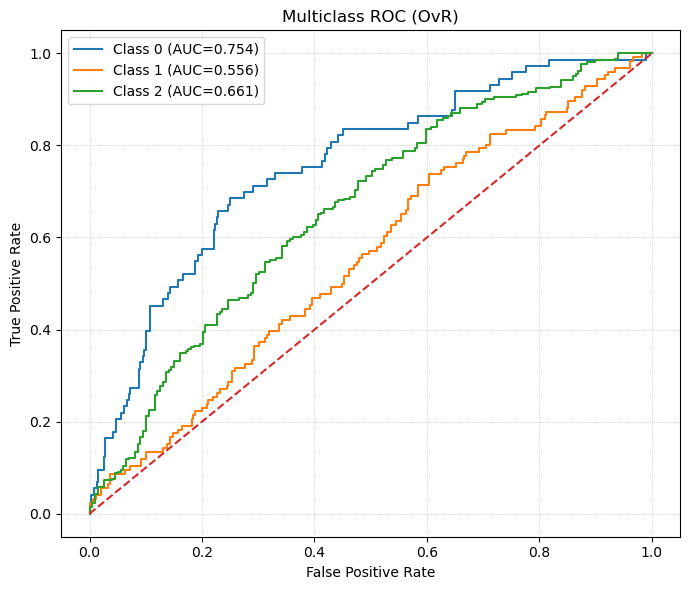

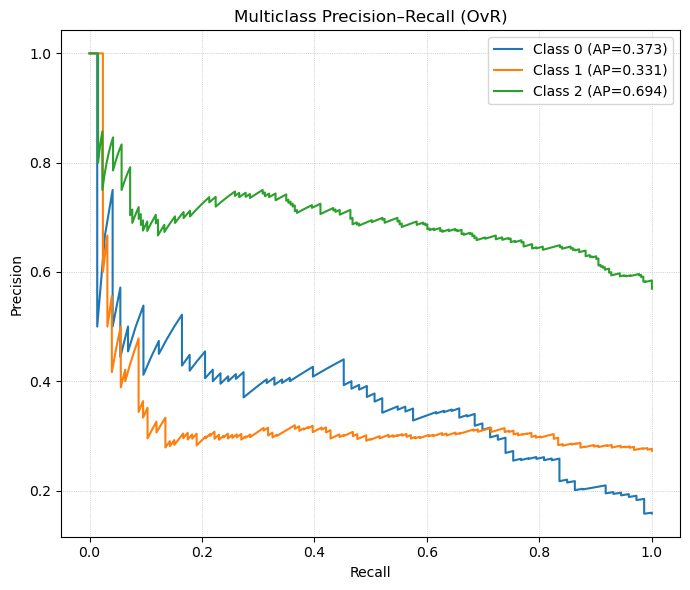


Dropped columns (>95% missing):
 - @12SHETE
 - @15SHETE
 - @9SHODE
 - LTB4
 - PGD2
 - PGE2
 - PGaaC341l
 - PGaaC361l
 - PGaaC362l

Top 10 features by remaining missingness in X (pre-imputation, post-encoding):
lysoPCaC160     93.07
PCaaC342        93.07
xLeu            93.07
H1              93.07
PCaaC362        93.07
PCaaC342l       82.60
Ala             82.55
Val             82.55
H1_energy_m     82.55
Lac_energy_m    82.55
dtype: float64

Final shapes: X_train=(1446, 127350), X_test=(462, 127350)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# ---------------------------
# 1) Load data
# ---------------------------
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
    low_memory=False
)

# Optional: numerisch aussehende Strings in floats konvertieren (z. B. "32,5")
obj_cols = df.select_dtypes(exclude=np.number).columns
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
    if num.notna().mean() >= 0.80:
        df[c] = num

# ---------------------------
# 2) Clean structure
#    - Drop columns that are mostly empty (>95% NaN)
#    - Drop rows that are entirely empty
# ---------------------------
before_cols = set(df.columns)
df = df.dropna(axis=1, thresh=int(len(df) * 0.05))  # keep cols with >=5% non-NaN
df = df.dropna(how="all")
dropped_cols = sorted(list(before_cols - set(df.columns)))

# ---------------------------
# 3) Target / features (MULTICLASS 0/1/2)
# ---------------------------
target_col = "OUTCOME_3Kat_KHK"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found after cleaning.")

df = df[df[target_col].notna()]
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)  # ensure 0/1/2

# ---------------------------
# 4) Encode categoricals (XGBoost needs numeric)
# ---------------------------
X = pd.get_dummies(X, drop_first=True)

# ---------------------------
# 5) Train-test split (stratified)
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Class distribution (train):")
print(y_train.value_counts(normalize=True).sort_index())
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True).sort_index())
print()

# ---------------------------
# 6) Imputation (median) — fit only on TRAIN, then transform both
#    (TomekLinks benötigt vollständige Daten)
# ---------------------------
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns,  index=X_test.index)

# ---------------------------
# 7) Tomek Links (Boundary-Cleaning) NUR auf TRAIN
#    - Für Multiclass ist 'sampling_strategy="all"' oft sinnvoll:
#      entfernt BEIDE Seiten eines Tomek-Paares (sauberes Boundary-Cleaning).
#    - Alternativ 'auto': entfernt nur Mehrheitsseite
# ---------------------------
from imblearn.under_sampling import TomekLinks

print("\nBefore TomekLinks:", y_train.value_counts(normalize=True).rename("proportion"))
tl = TomekLinks(sampling_strategy="all", n_jobs=-1)  # change to 'auto' if you prefer majority-only removal
X_train_tl, y_train_tl = tl.fit_resample(X_train_imp, y_train)
print("After  TomekLinks:", y_train_tl.value_counts(normalize=True).rename("proportion"))
print(f"Train size before TL: {len(y_train)} -> after TL: {len(y_train_tl)}\n")

# ---------------------------
# 8) Sample weights (Multiclass) nach TL
# ---------------------------
classes = np.sort(y_train_tl.unique())
class_wts = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_tl)
wt_map = {c: w for c, w in zip(classes, class_wts)}
sw_train = y_train_tl.map(wt_map).values

print("Class weights used (post-TL):")
for c in classes:
    print(f"  class {c}: {wt_map[c]:.4f}")
print()

# ---------------------------
# 9) XGBoost model (MULTICLASS)
# ---------------------------
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
)

# Early stopping (versions-robust)
fit_kwargs = dict(
    X=X_train_tl, y=y_train_tl,
    sample_weight=sw_train,
    eval_set=[(X_test_imp, y_test)],
    verbose=False
)
early_stopped = False
try:
    from xgboost.callback import EarlyStopping
    es = EarlyStopping(rounds=50, save_best=True, maximize=False)  # mlogloss -> minimize
    xgb_model.fit(**fit_kwargs, callbacks=[es]); early_stopped = True
except Exception:
    try:
        xgb_model.fit(**fit_kwargs, early_stopping_rounds=50); early_stopped = True
    except Exception:
        xgb_model.fit(**fit_kwargs)
print(f"Early stopping used: {early_stopped}")

# ---------------------------
# 10) Evaluation
# ---------------------------
y_pred = xgb_model.predict(X_test_imp)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# ---------------------------
# 11) Multiclass ROC and Precision–Recall curves (OvR)
# ---------------------------
y_score = xgb_model.predict_proba(X_test_imp)
classes_model = np.array(xgb_model.classes_)  # e.g., [0,1,2]
y_test_bin = label_binarize(y_test, classes=classes_model)

fpr, tpr, roc_auc = {}, {}, {}
precision, recall, avg_precision = {}, {}, {}
valid_classes_roc, valid_classes_pr = [], []

for i, c in enumerate(classes_model):
    y_true_i = y_test_bin[:, i]
    y_score_i = y_score[:, i]
    if y_true_i.any() and (~y_true_i.astype(bool)).any():
        fpr[i], tpr[i], _ = roc_curve(y_true_i, y_score_i)
        roc_auc[i] = auc(fpr[i], tpr[i])
        valid_classes_roc.append(i)
    if y_true_i.any():
        precision[i], recall[i], _ = precision_recall_curve(y_true_i, y_score_i)
        avg_precision[i] = average_precision_score(y_true_i, y_score_i)
        valid_classes_pr.append(i)

# Micro averages
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
avg_precision["micro"] = average_precision_score(y_test_bin, y_score, average="micro")

# Macro averages
roc_auc["macro"] = float(np.mean([roc_auc[i] for i in valid_classes_roc])) if valid_classes_roc else np.nan
avg_precision["macro"] = float(np.mean([avg_precision[i] for i in valid_classes_pr])) if valid_classes_pr else np.nan

print(f"\nROC AUC — micro: {roc_auc['micro']:.3f}, macro: {roc_auc['macro']:.3f}")
print(f"Avg Precision — micro: {avg_precision['micro']:.3f}, macro: {avg_precision['macro']:.3f}")

# --- Quick plots ---
plt.figure(figsize=(7, 6))
for i in valid_classes_roc:
    plt.plot(fpr[i], tpr[i], label=f"Class {classes_model[i]} (AUC={roc_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC (OvR)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
for i in valid_classes_pr:
    plt.plot(recall[i], precision[i], label=f"Class {classes_model[i]} (AP={avg_precision[i]:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass Precision–Recall (OvR)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# ---------------------------
# 12) (Optional) Show what was dropped
# ---------------------------
if dropped_cols:
    print("\nDropped columns (>95% missing):")
    for c in dropped_cols[:50]:
        print(" -", c)
    if len(dropped_cols) > 50:
        print(f"... and {len(dropped_cols) - 50} more")

# Remaining missingness (pre-imputation X)
missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)
print("\nTop 10 features by remaining missingness in X (pre-imputation, post-encoding):")
print(missing_pct.head(10).round(2))

print(f"\nFinal shapes: X_train={X_train_tl.shape}, X_test={X_test_imp.shape}")


## SECOND TRY

In [ ]:
# XGBoost (Binary) mit Cleaning: Dezimal-Komma, >75% Missing-Drop, OHE; robustes Early Stopping & ROC/PR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# ---------------------------
# 1) Daten laden (Dezimal-Komma + sauberes NaN-Parsing)
# ---------------------------
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
    low_memory=False
)

# ---------------------------
# 2) Obj->Float-Konvertierung für numerisch aussehende Spalten
# ---------------------------
obj_cols = df.select_dtypes(exclude=np.number).columns
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
    if num.notna().mean() >= 0.80:
        df[c] = num

# ---------------------------
# 3) Ziel & Features (binary mapping 0/1->0, 2->1)
# ---------------------------
target_col = "OUTCOME_3Kat_KHK"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

y = (df[target_col] == 2).astype(int)     # 1 = signifikant, 0 = keine/milde
X = df.drop(columns=[target_col])

mask_target = y.notna()
X, y = X.loc[mask_target].copy(), y.loc[mask_target].copy()

# ---------------------------
# 4) Spalten mit >75% Missing entfernen (nur auf X)
# ---------------------------
missing_threshold = 0.8
missing_ratio = X.isna().mean()
drop_cols = missing_ratio[missing_ratio > missing_threshold].index.tolist()
print(f"Dropping {len(drop_cols)} columns with >{int(missing_threshold*100)}% missingness.")
if drop_cols:
    print("Examples:", drop_cols[:10])
X = X.drop(columns=drop_cols)

# Zeilen entfernen, die in allen verbleibenden X-Spalten leer sind
row_mask = ~X.isna().all(axis=1)
X, y = X.loc[row_mask].copy(), y.loc[row_mask].copy()

# ---------------------------
# 5) Kategorik encoden (XGBoost braucht numerisch)
# ---------------------------
X = pd.get_dummies(X, drop_first=True)

# ---------------------------
# 6) Train-Test-Split (stratifiziert)
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True).rename("proportion").sort_index())
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True).rename("proportion").sort_index())

# ---------------------------
# 7) Klassenungleichgewicht: scale_pos_weight
# ---------------------------
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print(f"\nscale_pos_weight: {scale_pos_weight:.3f}")

# ---------------------------
# 8) XGBoost-Modell (binär)
# ---------------------------
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    objective="binary:logistic",
    eval_metric=["auc", "logloss"],
    scale_pos_weight=scale_pos_weight,
)

# -------- Versions-robustes Early Stopping --------
fit_kwargs = dict(
    X=X_train, y=y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

early_stopped = False
# 1) Versuche Callback-API
try:
    from xgboost.callback import EarlyStopping
    es = EarlyStopping(rounds=50, save_best=True, maximize=True)
    xgb_model.fit(**fit_kwargs, callbacks=[es])
    early_stopped = True
except Exception:
    # 2) Fallback: klassischer Parameter
    try:
        xgb_model.fit(**fit_kwargs, early_stopping_rounds=50)
        early_stopped = True
    except Exception:
        # 3) Notfalls ohne Early Stopping trainieren
        xgb_model.fit(**fit_kwargs)

print(f"\nEarly stopping used: {early_stopped}")

# ---------------------------
# 9) Evaluation (Binär)
# ---------------------------
y_pred = xgb_model.predict(X_test)
y_score = xgb_model.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1 (binary):", f1_score(y_test, y_pred, average="binary"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# ROC / PR
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_score)
avg_precision = average_precision_score(y_test, y_score)

print(f"\nROC AUC: {roc_auc:.3f}")
print(f"Average Precision (AP): {avg_precision:.3f}")

# --- ROC Curve ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Significant Stenosis vs None/Mild (XGBoost)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Precision–Recall Curve ---
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — Significant Stenosis (XGBoost)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# ---------------------------
# 10) Diagnostics
# ---------------------------
print("\nTop 15 features by remaining missingness in X (post-encoding):")
missing_pct_post = (X.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct_post.head(15).round(2))

print(f"\nFinal shapes: X_train={X_train.shape}, X_test={X_test.shape}")


## THIRD TRY

Dropping 537 columns with >82% missingness.
Examples: ['Omentin', 'Adiponectin_RIA', 'Ala', 'Arg', 'Asn', 'Asp', 'Cit', 'Gln', 'Glu', 'Gly']

Class distribution (train):
OUTCOME_3Kat_KHK
0    0.430736
1    0.569264
Name: proportion, dtype: float64

Class distribution (test):
OUTCOME_3Kat_KHK
0    0.430736
1    0.569264
Name: proportion, dtype: float64

Before TomekLinks: OUTCOME_3Kat_KHK
1    0.569264
0    0.430736
Name: proportion, dtype: float64
After  TomekLinks: OUTCOME_3Kat_KHK
1    0.53694
0    0.46306
Name: proportion, dtype: float64

scale_pos_weight (post-TL): 0.862

Early stopping used: False | TomekLinks used: True

Accuracy: 0.6774891774891775
Balanced accuracy: 0.6696505340390164
F1 (binary): 0.71939736346516

Confusion Matrix:
 [[122  77]
 [ 72 191]]

Classification Report:
               precision    recall  f1-score   support

           0      0.629     0.613     0.621       199
           1      0.713     0.726     0.719       263

    accuracy                        

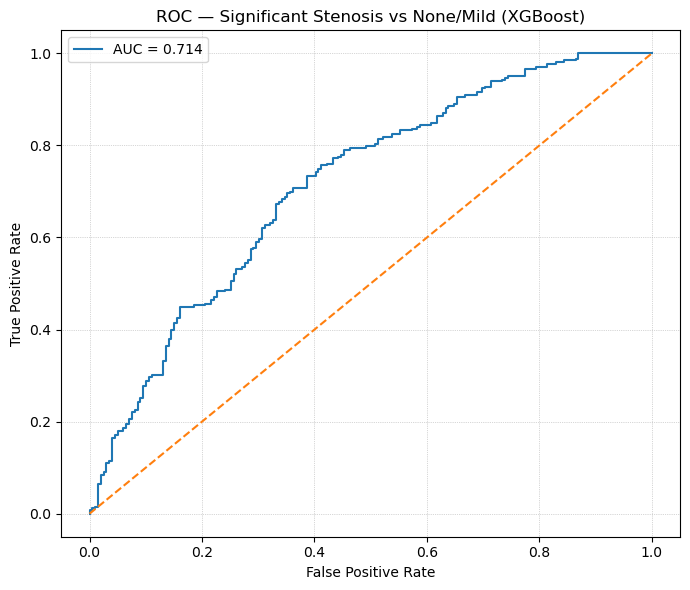

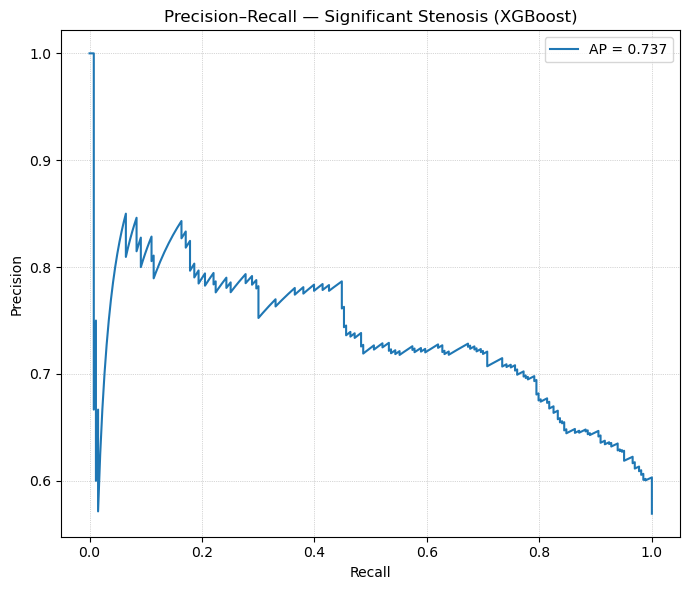


Top 15 features by remaining missingness in X (post-encoding):
Apelin                    78.92
ANGPL4                    78.66
CHEMERIN                  78.57
VISFATIN                  78.57
FETUIN_A_neu_berechnet    78.35
Uromodulin                77.10
CTRP1_restricted          76.54
Leptin_n                  76.32
RezLeptin                 76.10
Resistin                  76.10
Betatrophin               76.06
ProBNP_0                  67.45
GPC4_alle                 66.19
PHOSPHAT                  64.59
FGF23                     64.55
dtype: float64

Final shapes: X_train=(1719, 111), X_test=(462, 111)


In [8]:
# XGBoost (Binary) + Tomek Links + Cleaning: Dezimal-Komma, >75% Missing-Drop, OHE; robustes Early Stopping
# Binärziel: 1 = signifikante Stenose (orig. 2), 0 = keine/milde (orig. 0/1)

import warnings
warnings.filterwarnings("ignore")  # optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# --------------------------------------------------
# 1) Daten laden (Dezimal-Komma + NaN-Parsing)
# --------------------------------------------------
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
    low_memory=False
)

# --------------------------------------------------
# 2) Obj->Float-Konvertierung für numerisch aussehende Spalten
# --------------------------------------------------
obj_cols = df.select_dtypes(exclude=np.number).columns
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
    if num.notna().mean() >= 0.80:
        df[c] = num

# --------------------------------------------------
# 3) Ziel & Features (binary mapping 0/1->0, 2->1)
# --------------------------------------------------
target_col = "OUTCOME_3Kat_KHK"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

y = (df[target_col] == 2).astype(int)     # 1 = signifikant, 0 = keine/milde
X = df.drop(columns=[target_col])

mask_target = y.notna()
X, y = X.loc[mask_target].copy(), y.loc[mask_target].copy()

# --------------------------------------------------
# 4) Spalten mit >75% Missing entfernen (nur auf X)
# --------------------------------------------------
missing_threshold = 0.825
missing_ratio = X.isna().mean()
drop_cols = missing_ratio[missing_ratio > missing_threshold].index.tolist()
print(f"Dropping {len(drop_cols)} columns with >{int(missing_threshold*100)}% missingness.")
if drop_cols:
    print("Examples:", drop_cols[:10])
X = X.drop(columns=drop_cols)

# Zeilen entfernen, die in allen verbleibenden X-Spalten leer sind
row_mask = ~X.isna().all(axis=1)
X, y = X.loc[row_mask].copy(), y.loc[row_mask].copy()

# --------------------------------------------------
# 5) Kategorik encoden (XGBoost braucht numerisch)
# --------------------------------------------------
X = pd.get_dummies(X, drop_first=True)

# --------------------------------------------------
# 6) Train-Test-Split (stratifiziert)
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True).rename("proportion").sort_index())
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True).rename("proportion").sort_index())

# --------------------------------------------------
# 7) Imputation (nur auf Training fitten) -> macht TomekLinks möglich
# --------------------------------------------------
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns,  index=X_test.index)

# --------------------------------------------------
# 8) Tomek Links (Unter-Sampling der Mehrheitsklasse an der Grenze)
# --------------------------------------------------
tomek_used = True
try:
    from imblearn.under_sampling import TomekLinks
    print("\nBefore TomekLinks:", y_train.value_counts(normalize=True).rename("proportion"))
    tl = TomekLinks(sampling_strategy='auto', n_jobs=-1)   # löscht Mehrheitsseite der Konfliktpaare
    X_train_tl, y_train_tl = tl.fit_resample(X_train_imp, y_train)
    print("After  TomekLinks:", y_train_tl.value_counts(normalize=True).rename("proportion"))
except Exception as e:
    tomek_used = False
    print("\nTomekLinks konnte nicht ausgeführt werden.")
    print("Fehlermeldung:", e)
    X_train_tl, y_train_tl = X_train_imp, y_train  # Fallback: ohne TL

# --------------------------------------------------
# 9) Klassenungleichgewicht: scale_pos_weight (nach TL neu berechnen)
# --------------------------------------------------
pos = (y_train_tl == 1).sum()
neg = (y_train_tl == 0).sum()
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print(f"\nscale_pos_weight (post-TL): {scale_pos_weight:.3f}")

# --------------------------------------------------
# 10) XGBoost-Modell (binär)
# --------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    objective="binary:logistic",
    eval_metric=["auc", "logloss"],
    scale_pos_weight=scale_pos_weight,
)

# -------- Versions-robustes Early Stopping --------
fit_kwargs = dict(
    X=X_train_tl, y=y_train_tl,
    eval_set=[(X_test_imp, y_test)],
    verbose=False
)

early_stopped = False
try:
    from xgboost.callback import EarlyStopping
    es = EarlyStopping(rounds=50, save_best=True, maximize=True)
    xgb_model.fit(**fit_kwargs, callbacks=[es]); early_stopped = True
except Exception:
    try:
        xgb_model.fit(**fit_kwargs, early_stopping_rounds=50); early_stopped = True
    except Exception:
        xgb_model.fit(**fit_kwargs)

print(f"\nEarly stopping used: {early_stopped} | TomekLinks used: {tomek_used}")

# --------------------------------------------------
# 11) Evaluation (Binär)
# --------------------------------------------------
y_pred  = xgb_model.predict(X_test_imp)
y_score = xgb_model.predict_proba(X_test_imp)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1 (binary):", f1_score(y_test, y_pred, average="binary"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# ROC / PR
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_score)
avg_precision = average_precision_score(y_test, y_score)

print(f"\nROC AUC: {roc_auc:.3f}")
print(f"Average Precision (AP): {avg_precision:.3f}")

# --- ROC Curve ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Significant Stenosis vs None/Mild (XGBoost)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Precision–Recall Curve ---
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — Significant Stenosis (XGBoost)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 12) Diagnostics
# --------------------------------------------------
print("\nTop 15 features by remaining missingness in X (post-encoding):")
missing_pct_post = (X.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct_post.head(15).round(2))

print(f"\nFinal shapes: X_train={X_train_tl.shape}, X_test={X_test_imp.shape}")


## FOURTH TRY

In [ ]:
# XGBoost (Binary) + SMOTE + Cleaning: Dezimal-Komma, >75% Missing-Drop, OHE; robustes Early Stopping

import warnings
warnings.filterwarnings("ignore")  # optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# --------------------------------------------------
# 1) Daten laden (Dezimal-Komma + NaN-Parsing)
# --------------------------------------------------
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
    low_memory=False
)

# --------------------------------------------------
# 2) Obj->Float-Konvertierung für numerisch aussehende Spalten
# --------------------------------------------------
obj_cols = df.select_dtypes(exclude=np.number).columns
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
    if num.notna().mean() >= 0.80:
        df[c] = num

# --------------------------------------------------
# 3) Ziel & Features (binary mapping 0/1->0, 2->1)
# --------------------------------------------------
target_col = "OUTCOME_3Kat_KHK"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

y = (df[target_col] == 2).astype(int)      # 1 = signifikant, 0 = keine/milde
X = df.drop(columns=[target_col])

mask_target = y.notna()
X, y = X.loc[mask_target].copy(), y.loc[mask_target].copy()

# --------------------------------------------------
# 4) Spalten mit >75% Missing entfernen (nur auf X)
# --------------------------------------------------
missing_threshold = 0.75
missing_ratio = X.isna().mean()
drop_cols = missing_ratio[missing_ratio > missing_threshold].index.tolist()
print(f"Dropping {len(drop_cols)} columns with >{int(missing_threshold*100)}% missingness.")
if drop_cols:
    print("Examples:", drop_cols[:10])
X = X.drop(columns=drop_cols)

# Zeilen entfernen, die in allen verbleibenden X-Spalten leer sind
row_mask = ~X.isna().all(axis=1)
X, y = X.loc[row_mask].copy(), y.loc[row_mask].copy()

# --------------------------------------------------
# 5) Kategorik encoden (XGBoost braucht numerisch)
# --------------------------------------------------
X = pd.get_dummies(X, drop_first=True)

# --------------------------------------------------
# 6) Train-Test-Split (stratifiziert)
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True).rename("proportion").sort_index())
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True).rename("proportion").sort_index())

# --------------------------------------------------
# 7) Imputation (nur auf Training fitten) -> für SMOTE nötig
# --------------------------------------------------
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns,  index=X_test.index)

# --------------------------------------------------
# 8) SMOTE (Oversampling der Minderheitsklasse) nur auf Train
#    Adaptives k_neighbors, falls Minderheit sehr klein ist
# --------------------------------------------------
smote_used = True
try:
    from imblearn.over_sampling import SMOTE
    minority_class = 1 if (y_train_imp := y_train).value_counts().idxmin() == 1 else 0
    n_min = (y_train_imp == minority_class).sum()
    k = max(1, min(5, n_min - 1))  # SMOTE braucht mind. k+1 Minderheitsbeobachtungen
    print(f"\nSMOTE: minority={minority_class}, n_min={n_min}, k_neighbors={k}")

    sm = SMOTE(sampling_strategy="auto", k_neighbors=k, random_state=42, n_jobs=-1)
    X_train_sm, y_train_sm = sm.fit_resample(X_train_imp, y_train)
    print("After SMOTE:", y_train_sm.value_counts(normalize=True).rename("proportion"))
except Exception as e:
    smote_used = False
    print("\nSMOTE konnte nicht ausgeführt werden.")
    print("Fehlermeldung:", e)
    X_train_sm, y_train_sm = X_train_imp, y_train  # Fallback: ohne SMOTE

# --------------------------------------------------
# 9) Klassenungleichgewicht: scale_pos_weight (nach SMOTE neu)
# --------------------------------------------------
pos = (y_train_sm == 1).sum()
neg = (y_train_sm == 0).sum()
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print(f"\nscale_pos_weight (post-SMOTE): {scale_pos_weight:.3f}")

# --------------------------------------------------
# 10) XGBoost-Modell (binär)
# --------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    objective="binary:logistic",
    eval_metric=["auc", "logloss"],
    scale_pos_weight=scale_pos_weight,
)

# -------- Versions-robustes Early Stopping --------
fit_kwargs = dict(
    X=X_train_sm, y=y_train_sm,
    eval_set=[(X_test_imp, y_test)],
    verbose=False
)

early_stopped = False
try:
    from xgboost.callback import EarlyStopping
    es = EarlyStopping(rounds=50, save_best=True, maximize=True)
    xgb_model.fit(**fit_kwargs, callbacks=[es]); early_stopped = True
except Exception:
    try:
        xgb_model.fit(**fit_kwargs, early_stopping_rounds=50); early_stopped = True
    except Exception:
        xgb_model.fit(**fit_kwargs)
print(f"\nEarly stopping used: {early_stopped} | SMOTE used: {smote_used}")

# --------------------------------------------------
# 11) Evaluation (Binär)
# --------------------------------------------------
y_pred  = xgb_model.predict(X_test_imp)
y_score = xgb_model.predict_proba(X_test_imp)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1 (binary):", f1_score(y_test, y_pred, average="binary"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# ROC / PR
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_score)
avg_precision = average_precision_score(y_test, y_score)

print(f"\nROC AUC: {roc_auc:.3f}")
print(f"Average Precision (AP): {avg_precision:.3f}")

# --- ROC Curve ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Significant Stenosis vs None/Mild (XGBoost + SMOTE)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Precision–Recall Curve ---
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — Significant Stenosis (XGBoost + SMOTE)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 12) Diagnostics
# --------------------------------------------------
print("\nTop 15 features by remaining missingness in X (post-encoding):")
missing_pct_post = (X.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct_post.head(15).round(2))

print(f"\nFinal shapes: X_train={X_train_sm.shape}, X_test={X_test_imp.shape}")
